# 03 · What Many Systems Have in Common

Chapter 02 fit one system at a time and found that a short experiment leaves the coefficients
poorly determined. Suppose instead we have long historical recordings (80 s each) of 20 *other*
systems from the same family, e.g. from end-of-line tests. Can we learn, from this population, what
systems of this kind have in common, and package it into something a new system can borrow from?

---
## 1. Two steps: identify each system, then find the shared geometry

**Step 1: identify each training system.** With 80 s of data each, we obtain estimates
$\hat\eta_1,\dots,\hat\eta_{20}$ *and* their uncertainties: the Gauss–Newton covariance
$\hat\sigma_i^2(J_i^\top J_i)^{-1}$ of each fit, exactly as in chapter 02.

**Step 2: learn the geometry of the family.** We look for a low-dimensional description of how the
coefficients vary from system to system. Principal component analysis (PCA) finds the best
rank-$r$ affine approximation

$$
\hat\eta_i \approx \bar\eta + U z_i, \qquad z_i \in \mathbb R^r, \quad z_i \sim \mathcal N(0, I),
$$

where $\bar\eta$ is the average system and the columns of $U$ are the main directions of variation,
scaled so that the *task context* $z$ has unit variance across the family. $\bar\eta$ and $U$ are the
"pretrained backbone"; $z$ is the small part that changes from system to system. We also record the
typical size of the output residual $\hat\sigma$: the noise level a model should expect.

**A trap, and its fix.** Plain PCA looks for the directions of largest *spread* in the estimates.
But $\hat\eta_i$ spreads for two reasons: genuine differences between systems, and estimation
error. Chapter 02 showed that $\alpha$ is poorly identified, so its estimates scatter widely, and
plain PCA would spend a principal direction on this *noise*. The remedy is to measure every
coefficient in units of its own estimation uncertainty before running PCA (**noise-whitened PCA**, a
simple form of factor analysis): with $s_j$ the average estimation standard deviation of coefficient
$j$, PCA is applied to $(\hat\eta_{ij}-\bar\eta_j)/s_j$, and $U$ is mapped back to physical units.
Directions are then ranked by *signal-to-noise ratio* rather than raw spread.

---
## 2. Fitting the family

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import dynutils
from dynutils import sample_system, simulate, multisine, predict, fit_from_scratch, LOW

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR, NAMES = dynutils.COLOR, dynutils.NAMES

In [2]:
class Family:
    # Pretrained low-dimensional model of a family of systems.

    def fit(self, fits, data, rank=2, whiten=True):
        # fits: list of (eta_hat, covariance) from fit_from_scratch(..., return_cov=True)
        self.eta_hat = np.array([eta for eta, _ in fits])
        self.sigma = np.sqrt(np.mean([np.mean((predict(e, u) - y) ** 2)
                                      for e, (y, u) in zip(self.eta_hat, data)]))
        self.mean = self.eta_hat.mean(axis=0)
        self.scale = (np.sqrt(np.mean([np.diag(cov) for _, cov in fits], axis=0))
                      if whiten else np.ones(4))
        centred = (self.eta_hat - self.mean) / self.scale
        _, sv, vt = np.linalg.svd(centred, full_matrices=False)
        var = sv**2 / (len(centred) - 1)
        self.explained = var / var.sum()
        self.U = self.scale[:, None] * vt[:rank].T * np.sqrt(var[:rank])
        self.z_train = centred @ vt[:rank].T / np.sqrt(var[:rank])
        return self

    def decode(self, z):
        return np.clip(self.mean + np.asarray(z) @ self.U.T, LOW, dynutils.HIGH)

    def project(self, eta):
        # Best context for known coefficients, in the whitened metric (used only for evaluation).
        return np.linalg.lstsq(self.U / self.scale[:, None], (eta - self.mean) / self.scale, rcond=None)[0]


def r_squared(Z, C):
    # Share of the variance of the hidden variables C explained by an affine function of Z.
    A = np.c_[Z, np.ones(len(Z))]
    residual = C - A @ np.linalg.lstsq(A, C, rcond=None)[0]
    return 1 - (residual**2).sum(axis=0) / ((C - C.mean(axis=0)) ** 2).sum(axis=0)


train_systems = [sample_system(rng) for _ in range(20)]
train_data = []
for s in train_systems:
    u = multisine(800, rng, n=6)
    train_data.append((simulate(s, u, rng)[1], u))
train_fits = [fit_from_scratch(y, u, return_cov=True) for y, u in train_data]
family = Family().fit(train_fits, train_data)
naive = Family().fit(train_fits, train_data, whiten=False)
true_train = np.array([s["eta"] for s in train_systems])
hidden = np.array([s["context"] for s in train_systems])

print("Estimation std per coefficient (k, d, b, α):", np.round(family.scale, 4))
print("Variance explained by each principal direction:", np.round(family.explained, 3))
print(f"Estimated residual noise level sigma = {family.sigma:.4f}  (sensor noise alone: 0.01)")
print()
print("How well do the learned contexts explain the hidden design variables (R², 1 = perfectly)?")
for name, fam in (("plain PCA", naive), ("noise-whitened PCA", family)):
    r2 = r_squared(fam.z_train, hidden)
    print(f"  {name:>18s}:  c1 {r2[0]:.2f}   c2 {r2[1]:.2f}")

Estimation std per coefficient (k, d, b, α): [0.0107 0.0048 0.008  0.2976]
Variance explained by each principal direction: [0.832 0.146 0.018 0.004]
Estimated residual noise level sigma = 0.0190  (sensor noise alone: 0.01)

How well do the learned contexts explain the hidden design variables (R², 1 = perfectly)?
           plain PCA:  c1 0.98   c2 0.22
  noise-whitened PCA:  c1 0.99   c2 0.96


---
## 3. What the learned family looks like

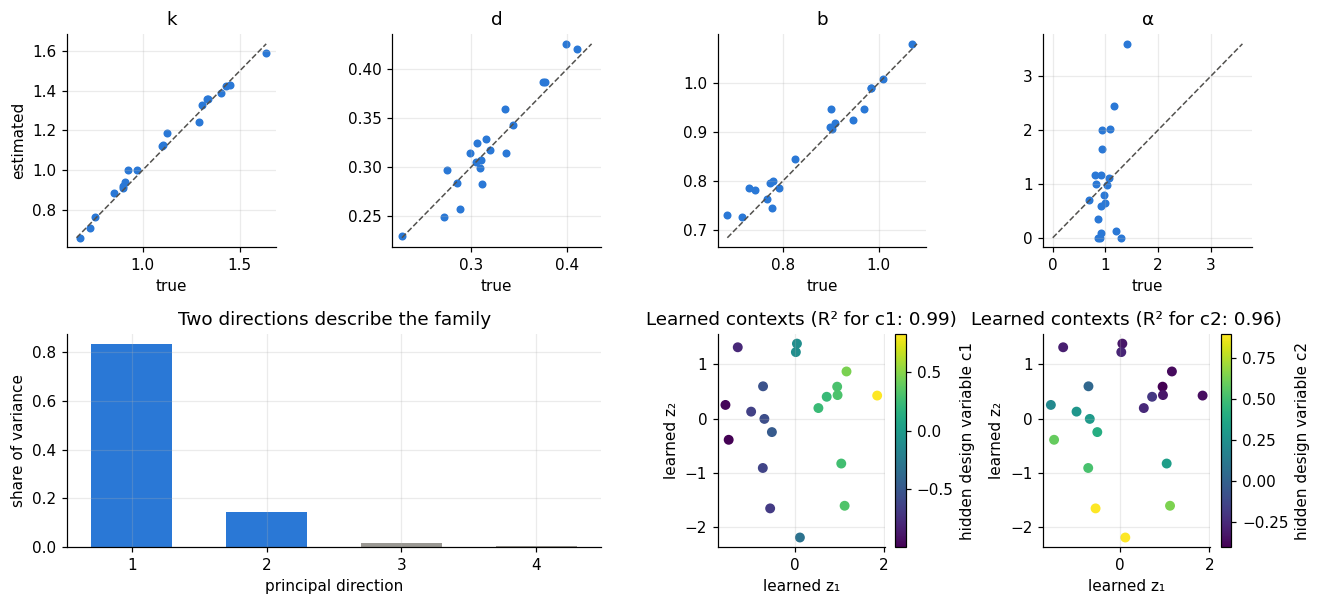

In [3]:
fig = plt.figure(figsize=(12, 5.6))
grid = fig.add_gridspec(2, 4)
for j in range(4):
    ax = fig.add_subplot(grid[0, j])
    ax.scatter(true_train[:, j], family.eta_hat[:, j], s=18, color=COLOR["context"])
    lim = [min(true_train[:, j].min(), family.eta_hat[:, j].min()),
           max(true_train[:, j].max(), family.eta_hat[:, j].max())]
    ax.plot(lim, lim, "--", color=COLOR["reference"], lw=1)
    ax.set(title=NAMES[j], xlabel="true", ylabel="estimated" if j == 0 else None)
ax = fig.add_subplot(grid[1, :2])
ax.bar(np.arange(1, 5), family.explained, color=[COLOR["context"]] * 2 + [COLOR["none"]] * 2, width=0.6)
ax.set(xticks=range(1, 5), xlabel="principal direction", ylabel="share of variance",
       title="Two directions describe the family")
r2 = r_squared(family.z_train, hidden)
for j in range(2):
    ax = fig.add_subplot(grid[1, 2 + j])
    sc = ax.scatter(*family.z_train.T, c=hidden[:, j], cmap="viridis", s=30)
    fig.colorbar(sc, ax=ax, label=f"hidden design variable c{j+1}")
    ax.set(xlabel="learned z₁", ylabel="learned z₂", title=f"Learned contexts (R² for c{j+1}: {r2[j]:.2f})")
plt.tight_layout(); plt.show()

- **Top row.** Stiffness, damping and gain are identified well from long recordings; $\alpha$ is only
  roughly determined (as chapter 02 predicted). Pretraining inherits these imperfections.
- **Bottom left.** Two directions explain almost all of the (noise-weighted) variation. The learner
  has discovered, from data alone, that the family is essentially two-dimensional.
- **Bottom right.** The learned coordinates $z$ encode both hidden design variables smoothly. They are
  a rotated and rescaled version of $c$: PCA cannot know the "names" of the hidden variables, and
  it does not need to.
- **The printout above** shows why the noise weighting matters. Plain PCA recovers the first design
  variable but largely misses the second, because it spends a direction on the scatter of the
  poorly identified $\alpha$. *What a model can learn from a population is limited by what can be
  identified in each of its members.*

This is the miniature version of a foundation model. A large model would replace the fixed physics
equation by a neural state-space model and PCA by a learned encoder. The division of labour stays
the same: **a shared backbone plus a small system-specific context.**

From here on, every chapter needs this pretrained family. `dynutils.build_family(rng)` rebuilds it
with exactly the code above, so calling it with a freshly-seeded
`rng = np.random.default_rng(dynutils.SEED)` reproduces this same family, deterministically, at the
top of every later chapter.

---
## Exercises

### Exercise 1: How many training systems does the family need?
Refit the family with only 5 and 10 training systems (reuse `train_systems[:5]` and
`train_systems[:10]` and their corresponding `train_data`/`train_fits`) and compare the variance
explained by the first two directions and the R² against the hidden design variables.

<details><summary>Solution</summary>

```python
for n in (5, 10, 20):
    fam_n = Family().fit(train_fits[:n], train_data[:n])
    r2_n = r_squared(fam_n.z_train, hidden[:n])
    print(f"n={n:>2d}: variance explained {fam_n.explained[:2].sum():.2f}, R² {r2_n[0]:.2f} {r2_n[1]:.2f}")
```
With only 5 systems the two-dimensional structure is already visible, but the learned axes are
noisier and their R² against the true design variables is markedly lower; 20 systems is enough for
the family to stabilise, which is why that is what the rest of the course reuses.
</details>

### Exercise 2: How much does whitening change the backbone itself?
Compare `family.mean` and `naive.mean` (both are the plain average of the 20 estimates, so they
should match) against `family.U` and `naive.U`. Which one points closer to the true mixing matrix
`_M` used by the simulator (up to rotation and scale, so compare the *subspaces* by looking at how
well each explains the hidden `context`, i.e. reuse the R² already printed above)?

<details><summary>Solution</summary>

Whitened PCA's R² (about 0.98 and 0.96 for c1 and c2) is far higher than plain PCA's (about 0.96 and
0.35), even though both share the same `mean`. The *directions* `U` differ because whitening
reweights each coefficient before finding them; only the whitened ones recover a subspace close to
the true `M @ c`, since plain PCA's second direction is dominated by α's estimation noise rather
than genuine variation.
</details>